In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# general purpose libraries

from datetime import datetime
import numpy as np
import pandas as pd
from sklearn.utils import shuffle
from matplotlib.font_manager import FontProperties
from collections import Counter
import matplotlib.pyplot as plt
from imblearn.over_sampling import BorderlineSMOTE
from sklearn.preprocessing import LabelEncoder

In [3]:
path_real_data = r"..\..\Data\9.Split-data for revision\Train_80\Parquet\\"

In [4]:
print("started...")
start_time = datetime.now()
num_samples = 1000000

# Read Parquet files
data_tomato_healthy = pd.read_parquet(path_real_data + "tomato_healthy.parquet", engine='pyarrow')[:num_samples]
data_tomato_unhealthy = pd.read_parquet(path_real_data + "tomato_unhealthy.parquet", engine='pyarrow')[:num_samples]
data_potato = pd.read_parquet(path_real_data + "potato.parquet", engine='pyarrow')[:num_samples]
data_chilli = pd.read_parquet(path_real_data + "chilli.parquet", engine='pyarrow').sample(frac=1)[:num_samples]
data_capsicum = pd.read_parquet(path_real_data + "capsicum.parquet", engine='pyarrow').sample(frac=1)[:num_samples]
data_mulberry = pd.read_parquet(path_real_data + "mulberry.parquet", engine='pyarrow').sample(frac=1)[:num_samples]

end_time = datetime.now()
print('Data loading time is:> {}'.format(end_time - start_time))

# Data shapes
print("tomato_healthy:", data_tomato_healthy.shape)
print("tomato_unhealthy:", data_tomato_unhealthy.shape)
print("data_potato:", data_potato.shape)
print("chilli:", data_chilli.shape)
print("capsicum:", data_capsicum.shape)
print("mulberry:", data_mulberry.shape)

started...
Data loading time is:> 0:00:00.886481
tomato_healthy: (2138, 944)
tomato_unhealthy: (119, 944)
data_potato: (616, 944)
chilli: (100, 944)
capsicum: (60, 944)
mulberry: (120, 944)


In [5]:
# Data Concatenating
df = pd.concat([data_tomato_healthy, data_tomato_unhealthy, data_potato, data_chilli, data_capsicum, data_mulberry], axis = 0)
df_final=df.copy()
df_final

,label,400,401,402,403,404,405,406,407,408,...,1333,1334,1335,1336,1337,1338,1339,1340,1341,1342
0,tomato_healthy,0.101378,0.101725,0.102485,0.103459,0.103914,0.104182,0.104880,0.106231,0.106578,...,0.547242,0.544077,0.541664,0.540310,0.538069,0.535569,0.534211,0.533388,0.531325,0.529307
1,tomato_healthy,0.103541,0.104723,0.105924,0.106492,0.106169,0.106725,0.107644,0.108090,0.108615,...,0.554549,0.550303,0.548048,0.545627,0.543121,0.542472,0.541165,0.537841,0.535955,0.536079
2,tomato_healthy,0.101660,0.102775,0.103691,0.103537,0.103872,0.105178,0.106558,0.107100,0.107503,...,0.532746,0.532024,0.530870,0.530600,0.527230,0.521051,0.519603,0.518942,0.516181,0.517180
3,tomato_healthy,0.104160,0.104660,0.105283,0.105518,0.106856,0.107884,0.108616,0.109425,0.110431,...,0.547227,0.543959,0.541547,0.539848,0.537445,0.535213,0.533859,0.532397,0.530679,0.530671
4,tomato_healthy,0.108282,0.109035,0.109674,0.109714,0.110377,0.111599,0.112497,0.112645,0.114480,...,0.559977,0.558477,0.555953,0.555026,0.552683,0.547314,0.546083,0.548683,0.547648,0.547143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,mulberry,0.150610,0.148311,0.147712,0.150745,0.143059,0.140830,0.144794,0.149432,0.142809,...,0.542970,0.539359,0.537040,0.534500,0.531990,0.530920,0.529303,0.526573,0.523556,0.520012
95,mulberry,0.177818,0.178394,0.177844,0.174123,0.174053,0.174596,0.175646,0.176550,0.170829,...,0.494575,0.492989,0.492455,0.490815,0.489857,0.491875,0.491671,0.488063,0.487661,0.490141
106,mulberry,0.067453,0.069221,0.067303,0.065067,0.065430,0.067561,0.068081,0.065086,0.065319,...,0.530755,0.527210,0.525040,0.521670,0.519943,0.520628,0.519001,0.515715,0.514204,0.513194
68,mulberry,0.206215,0.207254,0.207477,0.206704,0.199436,0.198757,0.203103,0.206120,0.200589,...,0.541877,0.541528,0.541698,0.545724,0.544454,0.538099,0.538018,0.540352,0.538783,0.539670


In [6]:
# Adding dummy class samples in df

dummy_df = df_final.loc[df_final['label']=='tomato_healthy']
dummy_df = pd.concat([dummy_df, dummy_df], ignore_index=True) # doubling the df
dummy_df['label'] = 'zummy'
dummy_df = dummy_df.head(3672)

df_final = pd.concat([df_final, dummy_df], ignore_index=True) # doubling the df
df_final

,label,400,401,402,403,404,405,406,407,408,...,1333,1334,1335,1336,1337,1338,1339,1340,1341,1342
0,tomato_healthy,0.101378,0.101725,0.102485,0.103459,0.103914,0.104182,0.104880,0.106231,0.106578,...,0.547242,0.544077,0.541664,0.540310,0.538069,0.535569,0.534211,0.533388,0.531325,0.529307
1,tomato_healthy,0.103541,0.104723,0.105924,0.106492,0.106169,0.106725,0.107644,0.108090,0.108615,...,0.554549,0.550303,0.548048,0.545627,0.543121,0.542472,0.541165,0.537841,0.535955,0.536079
2,tomato_healthy,0.101660,0.102775,0.103691,0.103537,0.103872,0.105178,0.106558,0.107100,0.107503,...,0.532746,0.532024,0.530870,0.530600,0.527230,0.521051,0.519603,0.518942,0.516181,0.517180
3,tomato_healthy,0.104160,0.104660,0.105283,0.105518,0.106856,0.107884,0.108616,0.109425,0.110431,...,0.547227,0.543959,0.541547,0.539848,0.537445,0.535213,0.533859,0.532397,0.530679,0.530671
4,tomato_healthy,0.108282,0.109035,0.109674,0.109714,0.110377,0.111599,0.112497,0.112645,0.114480,...,0.559977,0.558477,0.555953,0.555026,0.552683,0.547314,0.546083,0.548683,0.547648,0.547143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6820,zummy,0.056081,0.052691,0.051201,0.052921,0.051997,0.057097,0.061098,0.057186,0.056909,...,0.471524,0.467629,0.465384,0.461803,0.459312,0.459162,0.458067,0.455035,0.453808,0.455869
6821,zummy,0.048163,0.054170,0.059828,0.061424,0.060181,0.059028,0.058245,0.058094,0.062767,...,0.464959,0.461359,0.459250,0.458484,0.456810,0.454960,0.453148,0.450342,0.448766,0.448053
6822,zummy,0.060535,0.057681,0.059155,0.062156,0.056995,0.058057,0.063021,0.066011,0.066569,...,0.481685,0.479979,0.477516,0.475209,0.473914,0.472998,0.470828,0.468638,0.467381,0.464156
6823,zummy,0.048570,0.051756,0.053030,0.052696,0.050216,0.047460,0.043285,0.038604,0.045873,...,0.452903,0.449835,0.447598,0.446153,0.444617,0.442495,0.441331,0.441898,0.440606,0.437796


In [7]:
# visulization class distribution

def freq_visualize(df, title, xlim=3000):
    print(df['label'].value_counts())
    labels = df['label'].values
    counter = Counter(labels) # counter object
    counter = dict(sorted(counter.items())) # converting counter obj. into dictionary
    x = list(counter.keys())
    y = list(counter.values())
    plt.rcParams.update({'font.size':8})
    fig = plt.figure(num=None, figsize=(10, 4), dpi=200, facecolor='w', edgecolor='red')
    plt.barh(x, y)
    plt.xlim(0, xlim)
    plt.ylabel("Labels", weight ='bold')
    plt.xlabel("Frequencies", weight ='bold')
    plt.title(title)
    plt.show()

zummy               3672
tomato_healthy      2138
potato               616
mulberry             120
tomato_unhealthy     119
chilli               100
capsicum              60
Name: label, dtype: int64


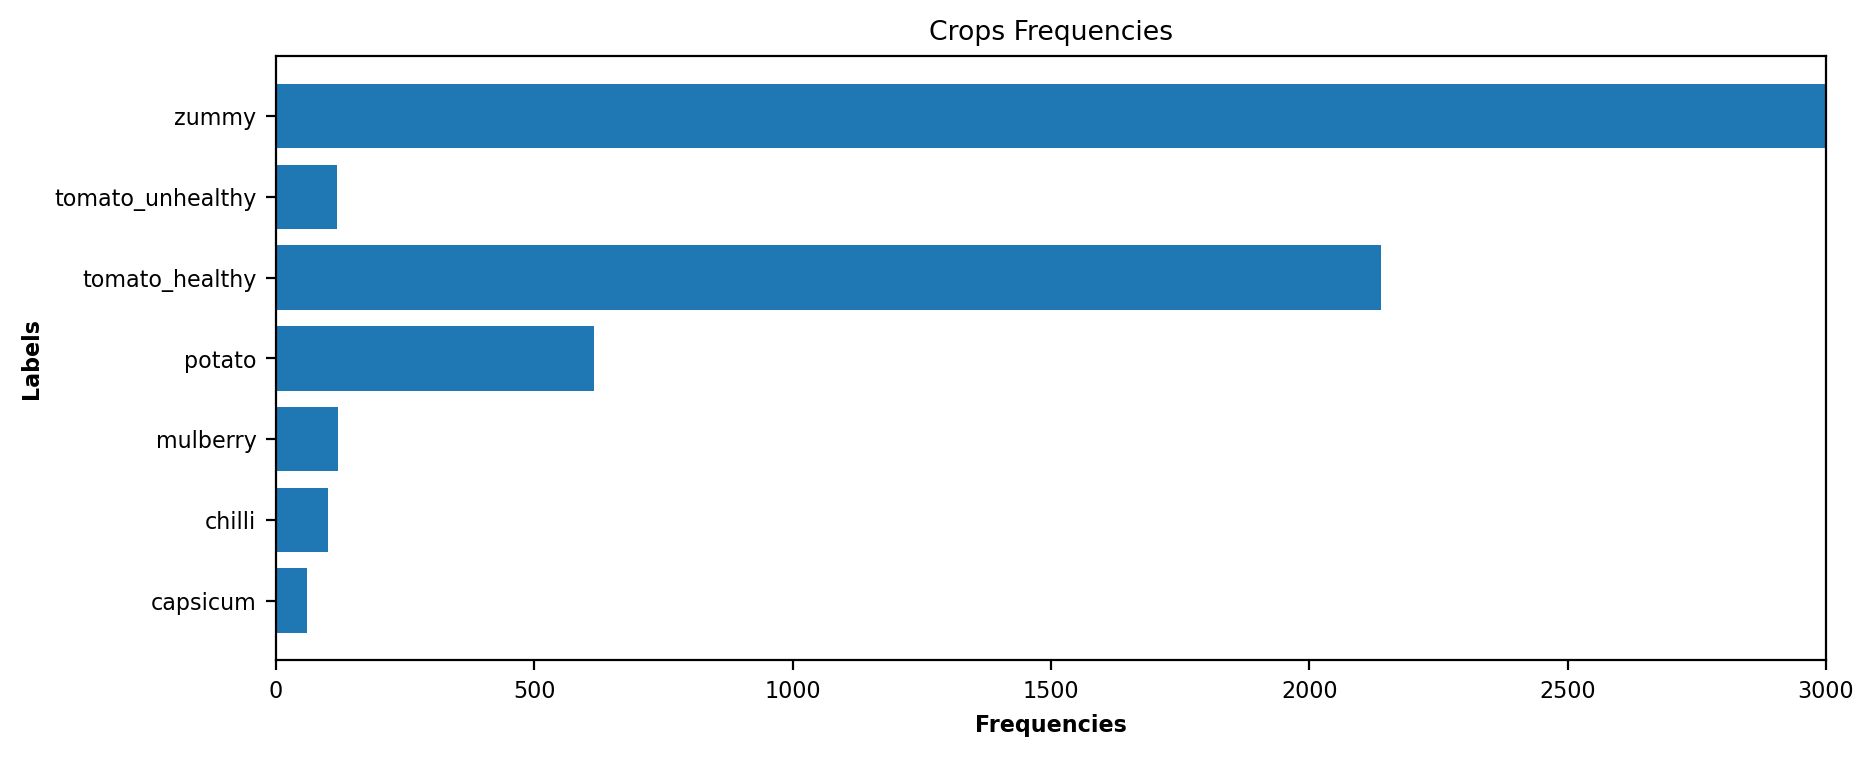

In [8]:
freq_visualize(df_final, title="Crops Frequencies")

In [9]:
# Generating X,y
X = df_final.drop("label",axis = 1)
y = df_final["label"]
print(X.shape, y.shape)

# Label encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(class_mapping)

(6825, 943) (6825,)
{'capsicum': 0, 'chilli': 1, 'mulberry': 2, 'potato': 3, 'tomato_healthy': 4, 'tomato_unhealthy': 5, 'zummy': 6}


In [10]:
# samples_per_class = {
#     "tomato_healthy":  1000,
#     "tomato_unhealthy":1000,    
#     "potato": 1000,    
#     "capsicum": 1000,  
#     "mulberry": 1000,      
#     "chilli":1000    
# }

In [11]:
# Applying Borderline SMOTE

target_per_class = 2000

sampling_strategy = {
    label: df_final['label'].value_counts()[label] + target_per_class
    for label in df_final['label'].unique()
}

bl_smote = BorderlineSMOTE(sampling_strategy=sampling_strategy, random_state=42, kind="borderline-1")

X_resampled, y_resampled = bl_smote.fit_resample(X,y)
X_resampled.shape

C:\Users\manoj\anaconda3\envs\tf\lib\site-packages\imblearn\utils\_validation.py:326: UserWarning: After over-sampling, the number of samples (4138) in class tomato_healthy will be larger than the number of samples in the majority class (class #zummy -> 3672)
  n_samples_majority,
C:\Users\manoj\anaconda3\envs\tf\lib\site-packages\imblearn\utils\_validation.py:326: UserWarning: After over-sampling, the number of samples (5672) in class zummy will be larger than the number of samples in the majority class (class #zummy -> 3672)
  n_samples_majority,


(20825, 943)

In [12]:
X_resampled

,400,401,402,403,404,405,406,407,408,409,...,1333,1334,1335,1336,1337,1338,1339,1340,1341,1342
0,0.101378,0.101725,0.102485,0.103459,0.103914,0.104182,0.104880,0.106231,0.106578,0.107553,...,0.547242,0.544077,0.541664,0.540310,0.538069,0.535569,0.534211,0.533388,0.531325,0.529307
1,0.103541,0.104723,0.105924,0.106492,0.106169,0.106725,0.107644,0.108090,0.108615,0.110195,...,0.554549,0.550303,0.548048,0.545627,0.543121,0.542472,0.541165,0.537841,0.535955,0.536079
2,0.101660,0.102775,0.103691,0.103537,0.103872,0.105178,0.106558,0.107100,0.107503,0.108327,...,0.532746,0.532024,0.530870,0.530600,0.527230,0.521051,0.519603,0.518942,0.516181,0.517180
3,0.104160,0.104660,0.105283,0.105518,0.106856,0.107884,0.108616,0.109425,0.110431,0.111627,...,0.547227,0.543959,0.541547,0.539848,0.537445,0.535213,0.533859,0.532397,0.530679,0.530671
4,0.108282,0.109035,0.109674,0.109714,0.110377,0.111599,0.112497,0.112645,0.114480,0.115504,...,0.559977,0.558477,0.555953,0.555026,0.552683,0.547314,0.546083,0.548683,0.547648,0.547143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20820,0.056016,0.057094,0.057247,0.056669,0.060107,0.061275,0.060663,0.060406,0.060566,0.060588,...,0.486951,0.485672,0.483291,0.478889,0.476997,0.477084,0.475717,0.474215,0.473548,0.472752
20821,0.367888,0.367119,0.366189,0.366004,0.365224,0.361851,0.359249,0.360054,0.358655,0.354895,...,0.166825,0.164699,0.163470,0.162482,0.161345,0.160986,0.160011,0.157710,0.156851,0.157404
20822,0.125875,0.122694,0.120511,0.121645,0.119130,0.123776,0.129446,0.128698,0.127782,0.127784,...,0.600949,0.597571,0.595161,0.594779,0.593188,0.589765,0.587891,0.587340,0.586279,0.584666
20823,0.369703,0.369186,0.367611,0.366068,0.365513,0.365308,0.363693,0.360181,0.360421,0.357883,...,0.168640,0.166970,0.165604,0.164360,0.163378,0.162986,0.162073,0.160681,0.160167,0.160448


In [13]:
# adding label and columns

resampled_df = pd.DataFrame(X_resampled, columns=X.columns)
resampled_df.insert(0, "label", y_resampled)
resampled_df

,label,400,401,402,403,404,405,406,407,408,...,1333,1334,1335,1336,1337,1338,1339,1340,1341,1342
0,tomato_healthy,0.101378,0.101725,0.102485,0.103459,0.103914,0.104182,0.104880,0.106231,0.106578,...,0.547242,0.544077,0.541664,0.540310,0.538069,0.535569,0.534211,0.533388,0.531325,0.529307
1,tomato_healthy,0.103541,0.104723,0.105924,0.106492,0.106169,0.106725,0.107644,0.108090,0.108615,...,0.554549,0.550303,0.548048,0.545627,0.543121,0.542472,0.541165,0.537841,0.535955,0.536079
2,tomato_healthy,0.101660,0.102775,0.103691,0.103537,0.103872,0.105178,0.106558,0.107100,0.107503,...,0.532746,0.532024,0.530870,0.530600,0.527230,0.521051,0.519603,0.518942,0.516181,0.517180
3,tomato_healthy,0.104160,0.104660,0.105283,0.105518,0.106856,0.107884,0.108616,0.109425,0.110431,...,0.547227,0.543959,0.541547,0.539848,0.537445,0.535213,0.533859,0.532397,0.530679,0.530671
4,tomato_healthy,0.108282,0.109035,0.109674,0.109714,0.110377,0.111599,0.112497,0.112645,0.114480,...,0.559977,0.558477,0.555953,0.555026,0.552683,0.547314,0.546083,0.548683,0.547648,0.547143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20820,zummy,0.056016,0.057094,0.057247,0.056669,0.060107,0.061275,0.060663,0.060406,0.060566,...,0.486951,0.485672,0.483291,0.478889,0.476997,0.477084,0.475717,0.474215,0.473548,0.472752
20821,zummy,0.367888,0.367119,0.366189,0.366004,0.365224,0.361851,0.359249,0.360054,0.358655,...,0.166825,0.164699,0.163470,0.162482,0.161345,0.160986,0.160011,0.157710,0.156851,0.157404
20822,zummy,0.125875,0.122694,0.120511,0.121645,0.119130,0.123776,0.129446,0.128698,0.127782,...,0.600949,0.597571,0.595161,0.594779,0.593188,0.589765,0.587891,0.587340,0.586279,0.584666
20823,zummy,0.369703,0.369186,0.367611,0.366068,0.365513,0.365308,0.363693,0.360181,0.360421,...,0.168640,0.166970,0.165604,0.164360,0.163378,0.162986,0.162073,0.160681,0.160167,0.160448


zummy               5672
tomato_healthy      4138
potato              2616
mulberry            2120
tomato_unhealthy    2119
chilli              2100
capsicum            2060
Name: label, dtype: int64


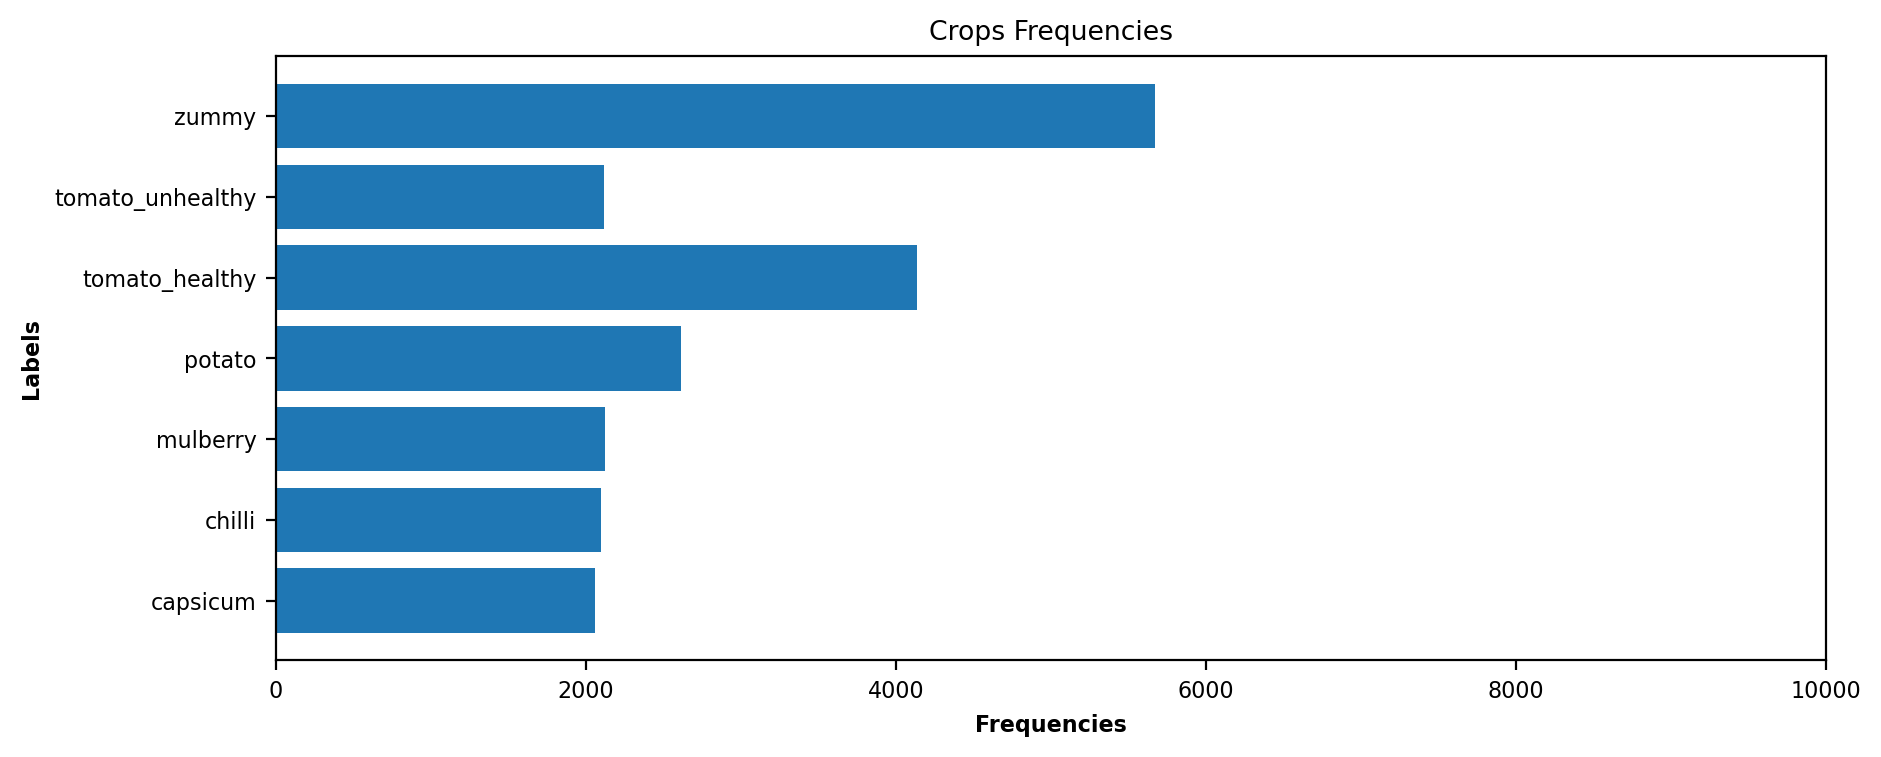

In [14]:
freq_visualize(resampled_df, title="Crops Frequencies", xlim=10000)

In [15]:
# Removing original samples from df | only SMOTE gen data will be remianed

resampled_df = resampled_df.iloc[len(df_final):].copy() # remove df_final length data from satrt
print(resampled_df.shape)

# group by crops
resampled_df.groupby(resampled_df.columns[0])

# crop and their count
print(resampled_df.iloc[:, 0].value_counts())

print("resampled_df.shape:", resampled_df.shape)
print("df_final.shape:", df_final.shape)

# Shuffeling

resampled_df = resampled_df.sample(frac = 1, random_state=None).reset_index(drop=True)
resampled_df = resampled_df.sample(frac = 1, random_state=None).reset_index(drop=True)

# removing NaN, inf, and -inf values
resampled_df = resampled_df[~resampled_df.isin([np.nan, np.inf, -np.inf]).any(axis = 1)]

resampled_df

(14000, 944)
capsicum            2000
tomato_unhealthy    2000
tomato_healthy      2000
zummy               2000
mulberry            2000
potato              2000
chilli              2000
Name: label, dtype: int64
resampled_df.shape: (14000, 944)
df_final.shape: (6825, 944)


,label,400,401,402,403,404,405,406,407,408,...,1333,1334,1335,1336,1337,1338,1339,1340,1341,1342
0,tomato_healthy,0.092685,0.095552,0.093702,0.089456,0.092235,0.093730,0.093574,0.092801,0.088336,...,0.144456,0.145175,0.144599,0.141871,0.142590,0.146238,0.146642,0.147332,0.147940,0.145046
1,capsicum,0.055515,0.053153,0.055764,0.061624,0.061857,0.059251,0.056555,0.055973,0.056837,...,0.337276,0.333729,0.332400,0.330795,0.329947,0.331847,0.331326,0.328130,0.327734,0.329844
2,tomato_unhealthy,0.078671,0.079882,0.080165,0.079200,0.080335,0.080782,0.080494,0.080188,0.080829,...,0.498659,0.496709,0.494390,0.491203,0.489269,0.488350,0.487240,0.486310,0.485995,0.486673
3,zummy,0.096073,0.095023,0.095540,0.097093,0.097085,0.098991,0.100596,0.099605,0.099333,...,0.464644,0.461355,0.459535,0.458083,0.456643,0.456654,0.455502,0.452754,0.451637,0.451562
4,tomato_unhealthy,0.078473,0.081028,0.083518,0.084681,0.086545,0.087645,0.086545,0.083772,0.085486,...,0.530101,0.527211,0.524711,0.521120,0.519185,0.519392,0.517884,0.515487,0.514139,0.511945
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13995,tomato_healthy,0.151614,0.152638,0.153639,0.154415,0.155480,0.156505,0.158015,0.160306,0.162088,...,0.600967,0.596967,0.593505,0.590541,0.588099,0.586367,0.584378,0.582476,0.581280,0.580589
13996,chilli,0.131132,0.130258,0.129617,0.128981,0.132854,0.131195,0.127520,0.127171,0.126423,...,0.690891,0.690752,0.688214,0.684041,0.682164,0.680943,0.678951,0.678088,0.676512,0.671810
13997,chilli,0.168045,0.167522,0.166477,0.164522,0.170692,0.170776,0.168958,0.171459,0.171365,...,0.619600,0.616134,0.614020,0.613225,0.610575,0.606789,0.604903,0.602293,0.600866,0.603158
13998,potato,0.125162,0.130025,0.132278,0.127671,0.112555,0.119719,0.135037,0.136778,0.120561,...,0.816322,0.815895,0.816878,0.813119,0.810360,0.815336,0.813487,0.796817,0.793780,0.805557


capsicum            2000
tomato_unhealthy    2000
tomato_healthy      2000
zummy               2000
mulberry            2000
potato              2000
chilli              2000
Name: label, dtype: int64


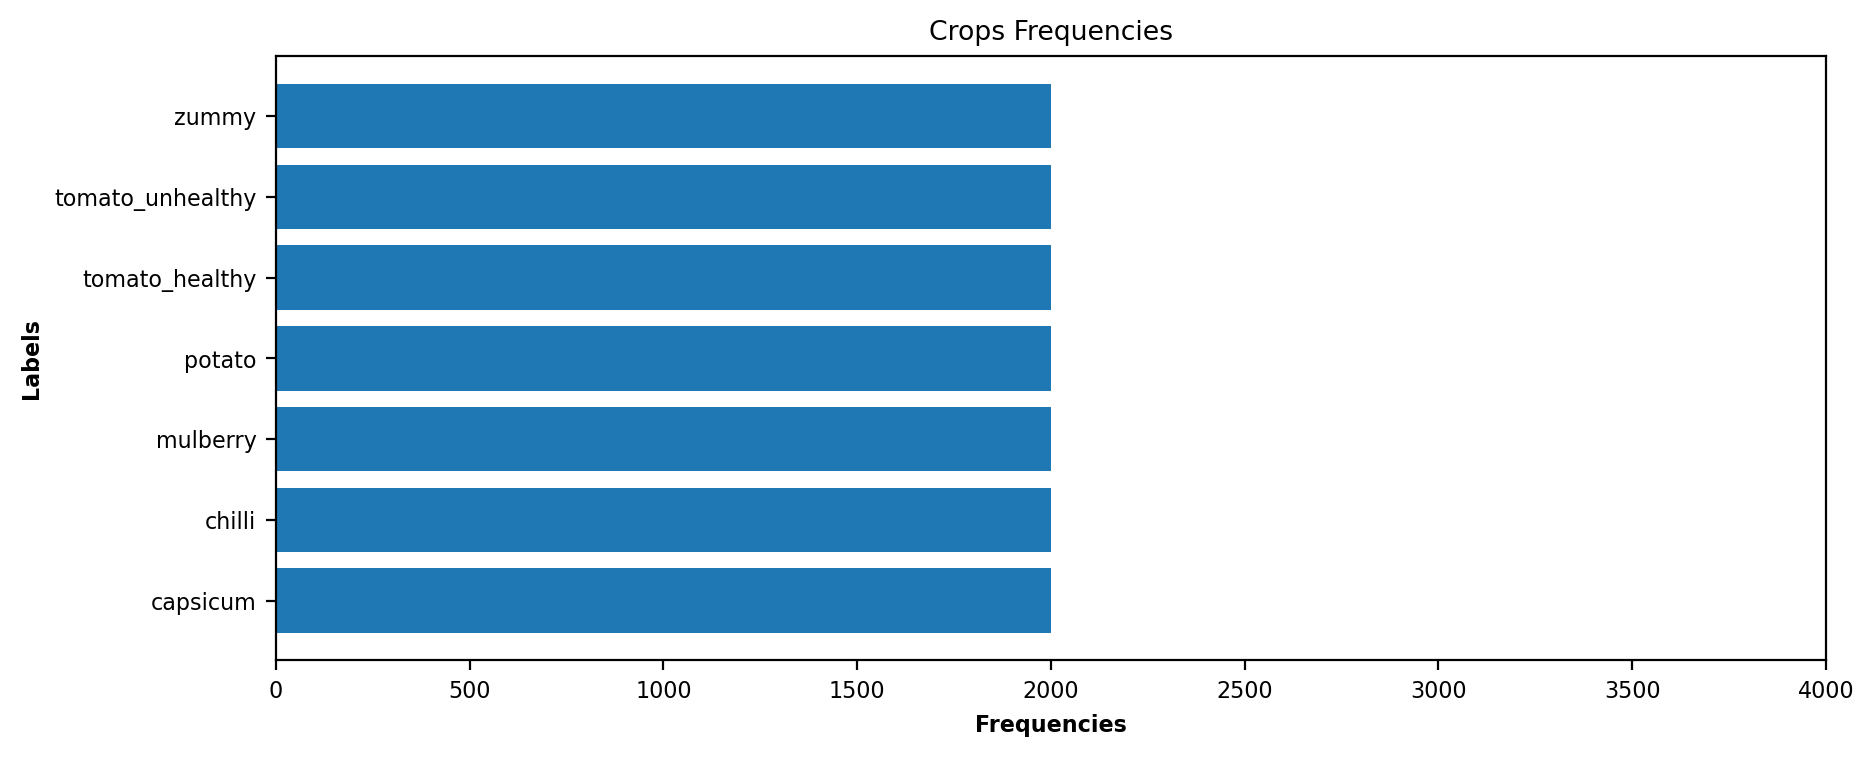

In [16]:
freq_visualize(resampled_df, title="Crops Frequencies", xlim=4000)

In [17]:
# taking individual crops data out

tomato_healthy = resampled_df.loc[resampled_df['label']=='tomato_healthy']
tomato_unhealthy = resampled_df.loc[resampled_df['label']=='tomato_unhealthy']
chilli = resampled_df.loc[resampled_df['label']=='chilli']
potato = resampled_df.loc[resampled_df['label']=='potato']
capsicum = resampled_df.loc[resampled_df['label']=='capsicum']
mulberry = resampled_df.loc[resampled_df['label']=='mulberry']

# Ensuring unique values
print(np.unique(tomato_healthy['label']))
print(np.unique(tomato_unhealthy['label']))
print(np.unique(chilli['label']))
print(np.unique(potato['label']))
print(np.unique(capsicum['label']))
print(np.unique(mulberry['label']))

['tomato_healthy']
['tomato_unhealthy']
['chilli']
['potato']
['capsicum']
['mulberry']


In [18]:
# Saving the data
tomato_healthy.to_excel(r"..\..\Data\5.Borderline_SMOTE\tomato_healthy.xlsx", index=False)
tomato_unhealthy.to_excel(r"..\..\Data\5.Borderline_SMOTE\tomato_unhealthy.xlsx", index=False)
capsicum.to_excel(r"..\..\Data\5.Borderline_SMOTE\capsicum.xlsx", index=False)
chilli.to_excel(r"..\..\Data\5.Borderline_SMOTE\chilli.xlsx", index=False)
potato.to_excel(r"..\..\Data\5.Borderline_SMOTE\potato.xlsx", index=False)
mulberry.to_excel(r"..\..\Data\5.Borderline_SMOTE\mulberry.xlsx", index=False)

In [19]:
# Saving the data in parquet format
import pandas as pd
from pathlib import Path

base_path = Path(r"..\..\Data\5.Borderline_SMOTE")

# Ensure directory exists
base_path.mkdir(parents=True, exist_ok=True)

# Save to Parquet
tomato_healthy.to_parquet(base_path / "tomato_healthy.parquet", index=False)
tomato_unhealthy.to_parquet(base_path / "tomato_unhealthy.parquet", index=False)
capsicum.to_parquet(base_path / "capsicum.parquet", index=False)
chilli.to_parquet(base_path / "chilli.parquet", index=False)
potato.to_parquet(base_path / "potato.parquet", index=False)
mulberry.to_parquet(base_path / "mulberry.parquet", index=False)

# Ploting real and Syn data in 3D

In [20]:
from common_fun import create_data, apply_pca, apply_TSNE, apply_UMAP, plot_3D, plot_3D_static

tomato_unhealthy real data shape: (119, 944)
tomato_unhealthy synthetic data shape: (2000, 944)


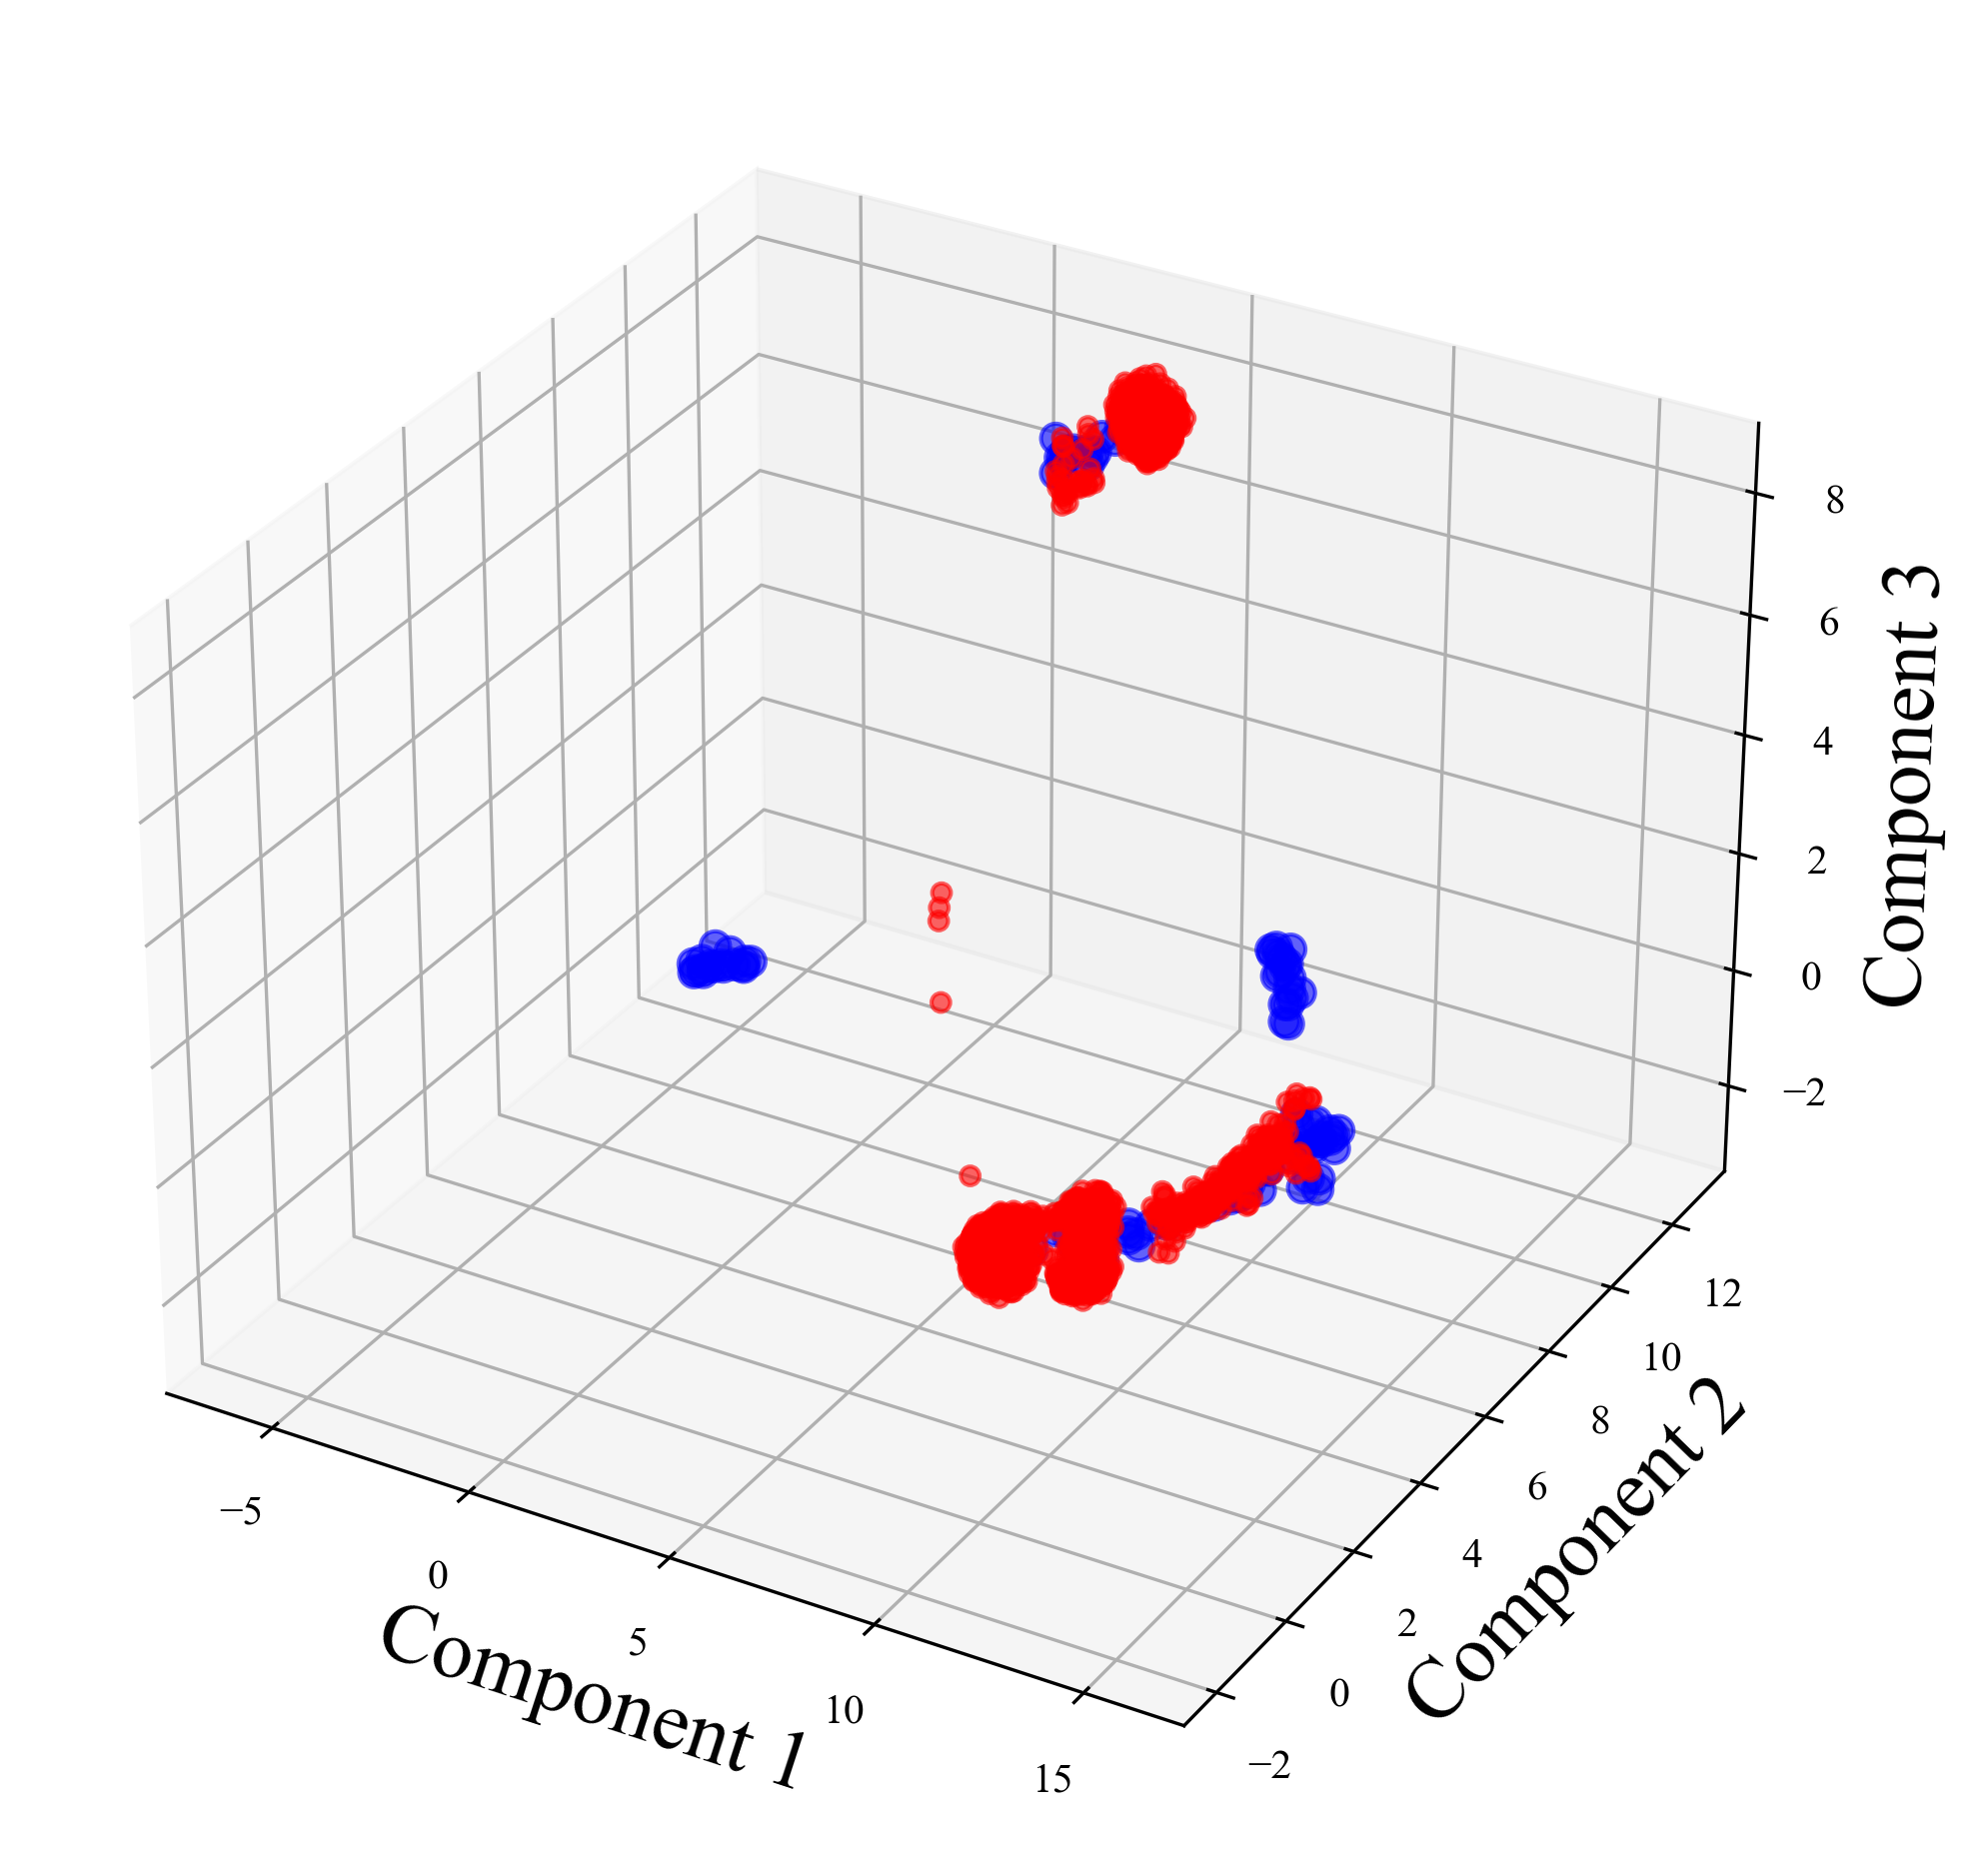

In [21]:
# tomato_healthy, tomato_unhealthy, chilli, potato, capsicum, mulberry
crop_name = "tomato_unhealthy" #capsicum, chilli, mulberry, potato, tomato_healthy, tomato_unhealthy
X_real_scaled, X_synthetic_scaled = create_data(crop_name, df_final, resampled_df)

# plot_df = apply_pca(X_real_scaled, X_synthetic_scaled)
# plot_3D(crop_name, plot_df, ptype="PCA")

# plot_df = apply_TSNE(X_real_scaled, X_synthetic_scaled)
# plot_3D(crop_name, plot_df, ptype="TSNE")

plot_df = apply_UMAP(X_real_scaled, X_synthetic_scaled)
plot_3D_static(crop_name, plot_df, ptype="UMAP")

# KL Divergence of Real Vs Syn data

In [22]:
from KLdivergence import kl_divergence

Overall KL Divergence by crop:
                  Overall KL
tomato_healthy      0.037787
tomato_unhealthy    5.894076
chilli              1.185993
potato              0.808580
capsicum           13.241025
mulberry            1.293877


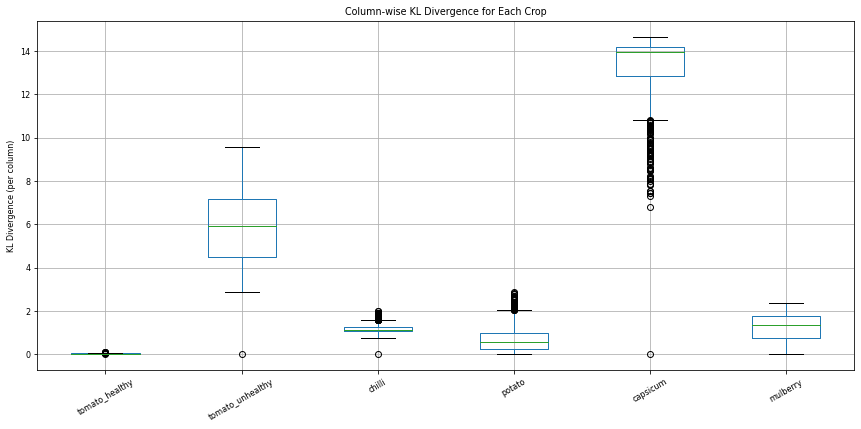

<Figure size 576x288 with 0 Axes>

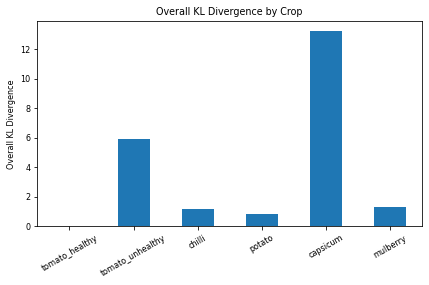

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

crop_names = ["tomato_healthy", "tomato_unhealthy", "chilli", "potato", "capsicum", "mulberry"]

# Store results for all crops
all_kl_scores = {}
overall_kl = {}

for crop in crop_names:
    real = df_final[df_final['label'] == crop]
    synth = resampled_df[resampled_df['label'] == crop]
    overall, kl_scores = kl_divergence(real, synth)
    all_kl_scores[crop] = kl_scores
    overall_kl[crop] = overall

# Convert overall KL to DataFrame for nice display
overall_kl_df = pd.DataFrame.from_dict(overall_kl, orient='index', columns=['Overall KL'])

print("Overall KL Divergence by crop:")
print(overall_kl_df)

# --- Plotting ---

# Plot per-column KL divergence (boxplot for each crop)
plt.figure(figsize=(12, 6))
kl_scores_df = pd.DataFrame(all_kl_scores)
kl_scores_df.boxplot()
plt.ylabel("KL Divergence (per column)")
plt.title("Column-wise KL Divergence for Each Crop")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Plot overall KL divergence bar plot
plt.figure(figsize=(8, 4))
overall_kl_df.plot(kind='bar', legend=False)
plt.ylabel("Overall KL Divergence")
plt.title("Overall KL Divergence by Crop")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()